In [1]:
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il
import random
import h5py
from scipy import stats

In [2]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

In [3]:
color_list = palette_tab10[2:3] + palette_tab10[4:5] + palette_tab10[1:2] 

In [4]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [5]:
snapnum = 40

In [6]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [7]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [8]:
h0 = 0.6774

In [9]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [10]:
group_sfrs = np.log10(halos["GroupSFR"])
#group_sfrs = halos["GroupSFR"]

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [11]:
fields = ["SubhaloSFR", # [Msun/yr]
          "SubhaloGrNr",
         "SubhaloFlag",
         "SubhaloPos",
         "SubhaloCM", "SubhaloHalfmassRad", "SubhaloHalfmassRadType", "SubhaloMass", "SubhaloBHMass",
         "SubhaloMassType", "SubhaloVmax", "SubhaloVmaxRad"] # [10^10 Msun/h]
print(len(fields))
subhalos = il.groupcat.loadSubhalos(f"{basePath}/output", snapnum, fields=fields)
print(type(subhalos))

12


<class 'dict'>


In [12]:
vmax = subhalos["SubhaloVmax"]
rmax = subhalos["SubhaloVmaxRad"]

In [13]:
cent_vmax1 = subhalos["SubhaloVmax"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]
cent_vmax = np.zeros(len(mvir))
cent_vmax[halos["GroupFirstSub"]>-1] = cent_vmax1

In [14]:
cent_rmax1 = subhalos["SubhaloVmaxRad"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]
cent_rmax = np.zeros(len(mvir))
cent_rmax[halos["GroupFirstSub"]>-1] = cent_rmax1

In [15]:
cent_cprox = cent_vmax/cent_rmax

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in true_divide
  """Entry point for launching an IPython kernel.


In [16]:
cent_mask_all = np.full(len(subhalos["SubhaloSFR"]), False)
cent_mask_all[halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]] = True

In [17]:
cent_sfrs1 = subhalos["SubhaloSFR"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]

In [18]:
cent_sfrs = np.zeros(len(mvir))
cent_sfrs[halos["GroupFirstSub"]>-1] = cent_sfrs1
cent_sfrs = np.log10(cent_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


### Satellite SFR

In [19]:
sat_sfrs = subhalos["SubhaloSFR"][~cent_mask_all]

In [20]:
sat_mass = subhalos["SubhaloMass"][~cent_mask_all]*1e10

In [21]:
sat_ids = subhalos["SubhaloGrNr"][~cent_mask_all]
unique_ids, indices = np.unique(sat_ids, return_index=True)

In [22]:
sum_sfrs1 = np.add.reduceat(sat_sfrs, indices)

In [39]:
sat_max_sfrs1 = np.maximum.reduceat(sat_sfrs, indices)

In [51]:
split_sfrs = np.split(sat_sfrs, indices[1:])  # Split sat_sfrs based on indices
mean_sfrs = np.array([np.mean(group) for group in split_sfrs])

In [55]:
split_sfrs = np.split(sat_sfrs, indices[1:])  # Split sat_sfrs based on indices
median_sfrs = np.array([np.median(group) for group in split_sfrs])

In [23]:
sum_sfrs = np.zeros(len(group_sfrs))
sum_sfrs[unique_ids] = sum_sfrs1
sum_sfrs = np.log10(sum_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


In [40]:
sat_max_sfrs = np.zeros(len(group_sfrs))
sat_max_sfrs[unique_ids] = sat_max_sfrs1
sat_max_sfrs = np.log10(sat_max_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


In [56]:
sat_max_sfrs = np.zeros(len(group_sfrs))
sat_max_sfrs[unique_ids] = median_sfrs
sat_max_sfrs = np.log10(sat_max_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


In [24]:
sum_mass1 =  np.add.reduceat(sat_mass, indices)

In [25]:

sum_sat_mass = np.zeros(len(group_sfrs))
sum_sat_mass[unique_ids] = sum_mass1
sum_sat_mass = np.log10(sum_sat_mass)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in log10
  after removing the cwd from sys.path.


In [26]:
sfr_types = [cent_sfrs, sum_sfrs, group_sfrs]

In [27]:
dlogM = 0.1
mbins = np.arange(10,13.71,dlogM)
mbins2 = np.array([13.8, 14.2])
mbins = np.concatenate((mbins, mbins2))
mbin_cents = (mbins[1:] + mbins[:-1])/2


coef_list = []
perr_list = []
for i, m in enumerate(mbins[:-1]):
    mask = (mvir > mbins[i]) & (mvir < mbins[i+1]) & (group_sfrs > -5) #& (np.isnan(frac_cent) == False)#& (np.isnan(c200c)==False)
    # frac = np.sum(mask)/np.sum((mvir > mcent - dlogM/2) & (mvir < mcent + dlogM/2) )
    # frac_list.append(frac)
    coef1 = stats.spearmanr(cent_sfrs[mask],sum_sfrs[mask])
    coef = coef1[0]
    perr = coef1[1]
    if np.sum(mask) < 5:
        coef = np.nan
        #print(mcent)
    coef_list.append(coef)
    perr_list.append(perr)


(11.0, 14.4)

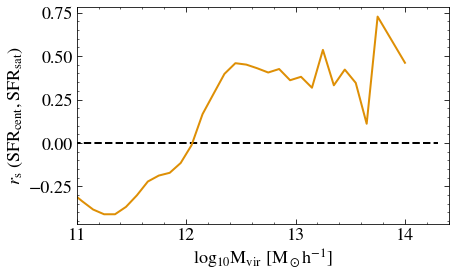

In [28]:
plt.plot([10,14.3], [0,0], linestyle="dashed", c="k")

plt.plot(mbin_cents, coef_list, color=color_list[2])

plt.xlabel(r"log$_{10}$M$_{\rm vir}$ [M$_\odot$h$^{-1}$]")
plt.ylabel(r"$r_\mathrm{s}\ \rm(SFR_{cent}, SFR_{sat})$")
# ax = plt.gca()
# h, l =  ax.get_legend_handles_labels()
# leg1 = plt.legend(handles=h[2:], labels=l[2:], loc = "lower right", ncol=2)
# ax.add_artist(leg1)
# leg2 = plt.legend(handles=h[:2], labels=l[:2], loc = "upper left", bbox_to_anchor=(0,0.9))
plt.xlim(11,14.4)
#plt.savefig("../figures/corr_coef_sfr_cent_sat.pdf", format="pdf", bbox_inches="tight")

No handles with labels found to put in legend.


SpearmanrResult(correlation=0.4591398125727872, pvalue=5.559234214527518e-94)


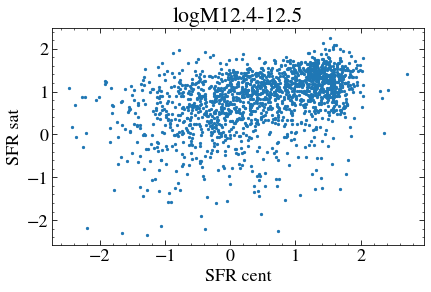

In [38]:
logM = 12.4
dlogM=0.1
mask_mass = (mvir > logM) & (mvir < logM+dlogM)

mask = mask_mass & (group_sfrs > -5) #& (np.isnan(property1) == False) & (property1 > percentiles[ip]) & (property1 < percentiles[ip+1])
plt.scatter(cent_sfrs[mask],sum_sfrs[mask], s=5)
coef1 = stats.spearmanr(cent_sfrs[mask],sum_sfrs[mask])
print(coef1)
plt.title(f"logM{logM}-{logM+dlogM}")
plt.xlabel("SFR cent")
plt.ylabel("SFR sat")
plt.legend()

No handles with labels found to put in legend.


SpearmanrResult(correlation=-0.3011562770175754, pvalue=0.0)


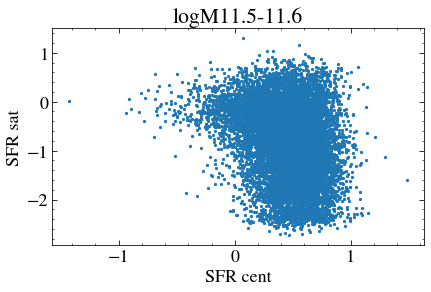

In [35]:
logM = 11.5
dlogM=0.1
mask_mass = (mvir > logM) & (mvir < logM+dlogM)

mask = mask_mass & (group_sfrs > -5) #& (np.isnan(property1) == False) & (property1 > percentiles[ip]) & (property1 < percentiles[ip+1])
plt.scatter(cent_sfrs[mask],sum_sfrs[mask], s=5)
coef1 = stats.spearmanr(cent_sfrs[mask],sum_sfrs[mask])
plt.title(f"logM{logM}-{logM+dlogM}")
print(coef1)
plt.xlabel("SFR cent")
plt.ylabel("SFR sat")
plt.legend()

SpearmanrResult(correlation=0.04147032499958523, pvalue=0.0795023340893995)
SpearmanrResult(correlation=0.4591398125727872, pvalue=5.559234214527518e-94)


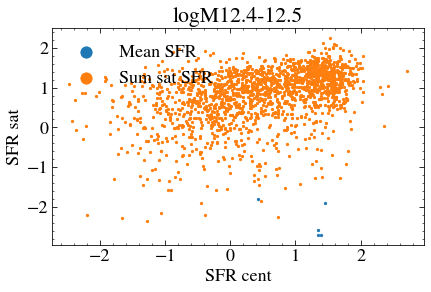

In [57]:
logM = 12.4
dlogM=0.1
mask_mass = (mvir > logM) & (mvir < logM+dlogM)

mask = mask_mass & (group_sfrs > -5) #& (np.isnan(property1) == False) & (property1 > percentiles[ip]) & (property1 < percentiles[ip+1])
plt.scatter(cent_sfrs[mask],sat_max_sfrs[mask], s=5, label="Mean SFR")
coef1 = stats.spearmanr(cent_sfrs[mask],sat_max_sfrs[mask])
print(coef1)

plt.scatter(cent_sfrs[mask],sum_sfrs[mask], s=5, label="Sum sat SFR")
coef1 = stats.spearmanr(cent_sfrs[mask],sum_sfrs[mask])

print(coef1)
plt.title(f"logM{logM}-{logM+dlogM}")
plt.xlabel("SFR cent")
plt.ylabel("SFR sat")
plt.legend(loc="upper left", markerscale=5)

## Single haloes

In [62]:
cent_mask1 = np.full(len(subhalos["SubhaloSFR"]), False)
cent_mask1[halos["GroupFirstSub"][mask_mass][halos["GroupFirstSub"][mask_mass]>-1]] = True

sat_sfrs2 = subhalos["SubhaloSFR"][~cent_mask1]
sat_ids2 = subhalos["SubhaloGrNr"][~cent_mask1]
unique_ids2, indices2 = np.unique(sat_ids2, return_index=True)

In [64]:
split_sfrs = np.split(sat_sfrs2, indices[1:])  # Split sat_sfrs based on indices

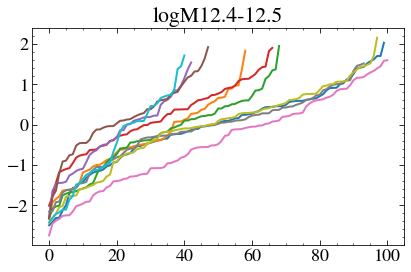

In [76]:
plt.title(f"logM{logM}-{logM+dlogM}")
for i in range(10):
    plt.plot(np.log10(np.sort(split_sfrs[i][split_sfrs[i]>0])))

In [71]:
split_sfrs

[array([106.96627 ,  50.129147,  13.217974, ...,   0.      ,   0.      ,
          0.      ], dtype=float32),
 array([0.00000000e+00, 6.81290894e+01, 4.59864235e+00, 2.32733517e+01,
        4.64023018e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 7.82268143e+00, 0.00000000e+00, 1.98057103e+00,
        2.37565845e-01, 9.43428898e+00, 3.48668623e+00, 3.81459332e+00,
        7.68428898e+00, 0.00000000e+00, 0.00000000e+00, 1.88883841e+00,
        3.39331686e-01, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 1.84748971e+00, 3.87126654e-01,
        2.33262229e+00, 6.63321078e-01, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.18872738e+00, 0.00000000e+00, 2.72063404e-01,
        3.26806694e-01, 2.70407856e-01, 0.00000000e+00, 1.31651297e-01,
        0.00000000e+00, 6.52396008e-02, 2.42844179e-01, 9.13438126e-02,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.16238582e+00,
        2.06513658e-01, 0.